# EDA

### 디렉토리 구조 ###
```bash
sprint_ai_project1_data/
├── test_images/                                  # 📷 [1번 촬영 이미지] (알약 최대 4개 포함)
├── train_images/                                 # 📷 [2번 촬영 이미지]
└── train_annotations/
    ├── K-001900-016548-019607-033009_json/       # 📁 1. 알약 조합 폴더(총 114개)
    │   │
    │   ├── K-001900/                            # 📁 첫 번째 알약 종류
    │   │   ├── K-001900-..._0_2_0_2_7...json    # 📁 [Annotation 파일] 특정 각도/조명 조건의 라벨
    │   │   ├── K-001900-..._0_2_0_2_8...json
    │   │   └── K-001900-..._0_2_0_2_9...json
    │   ├── K-016548/                            # 두 번째 알약 종류
    │   │   ├── K-001900-..._0_2_0_2_7...json
    │   │   └── ...
    │   ├── K-019607/                            # 세 번째 알약 종류
    │   │   └── ...
    │   └── K-033009/                            # 네 번째 알약 종류
    │       └── ...
    ├── K-001900-016548-021771-027926_json/       # 다른 알약 조합 폴더
    └── ... 
```

In [1]:
#@title 라이브러리 임포트

import matplotlib.pyplot as plt 
import seaborn as sns

import json
import glob
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import os



### 데이터 확인 ###

In [2]:
path = 'c://Bootcamp/project/pill-detection-ai/data/raw/sprint_ai_project1_data'

train_img_path = os.path.join(path, 'train_images')
train_ann_path = os.path.join(path, 'train_annotations')
test_img_path = os.path.join(path, 'test_images')

train_imgs = [obj for obj in os.listdir(train_img_path) if obj.endswith(('png','jpg','jpeg'))]

train_anns = []
for root, dirs, files in os.walk(train_ann_path):
    for file in files:
        if file.endswith('.json'):
            train_anns.append(file)

test_imgs = [obj for obj in os.listdir(test_img_path) if obj.endswith(('png','jpg','jpeg'))]



# 데이터 수량
print(f'train images: {len(train_imgs)}개')
print(f'train annotations: {len(train_anns)}개')
print(f'test images: {len(test_imgs)}개')

train images: 232개
train annotations: 763개
test images: 842개


데이터 수량확인 결과 train images와 annotations의 수량이 다름  
-> 이미지 하나당 여러 개의 annotation을 가지고 있는 것으로 보임

In [3]:
#@title annotation 파일 분석
from pathlib import Path
json_path = next(Path(train_ann_path).rglob('*.json'), None)

if not json_path:
    print('JSON파일을 찾지 못했습니다.')

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Key 목록과 각 Key의 데이터 타입 확인
print("Key 및 데이터 타입 목록:")
if isinstance(data, dict):
    for key, value in data.items():
        print(f"- {key} ({type(value).__name__}): {value}")
elif isinstance(data, list):
    print(f"최상위 구조가 List 형태입니다. 총 {len(data)}개의 요소가 있습니다.")
    if len(data) > 0:
        print(f"첫 번째 요소 타입: {type(data[0]).__name__}")

Key 및 데이터 타입 목록:
- images (list): [{'file_name': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 70, 'camera_lo': 0, 'size': 200, 'dl_idx': '1900', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date': '19870323', 'di_class_no': '[01170]정신신경용제', 'di_etc_otc_code': '전문의약품', 'di_edi_code': '641901280,A09302381', 'chart': '이약은 양면볼록한 장방형의 흰색정제이다', 'drug_shape': '장방형', 'thick': 2.5, 'leng_long': 8, 'leng_short': 4.5, 'print_

annotation파일이 알약별로 나뉘고, 각도 등 세부 특징으로 다시 한 번 세분화됨(파일 상단 디렉토리 구조 참조)  
-> 학습에 사용하기 위해서는 이미지별로 annotation파일 병합 필요

In [4]:
# annotation 파일 병합 및 필요한 정보 추출
def get_ann_for_image(image_path, annotation_path):
    image_name = os.path.splitext(os.path.basename(image_path))[0]

    # 이미지 파일명에서 조합 ID 추출
    group_id = image_name.split('_')[0]
    folder_name = f'{group_id}_json'

    search_path = os.path.join(annotation_path, folder_name, '*', f'{image_name}.json')
    matched_json_files = glob.glob(search_path)

    boxes = []
    labels = []
    # 찾은 JSON파일들을 읽어서 Bounding Box 및 Class 정보 병합
    for json_file in matched_json_files:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        boxes.append(data['annotations'][0]['bbox'])
        labels.append(data['images'][0]['dl_mapping_code'])

        
    return {'image': image_path, 'bboxes': boxes, 'labels': labels}

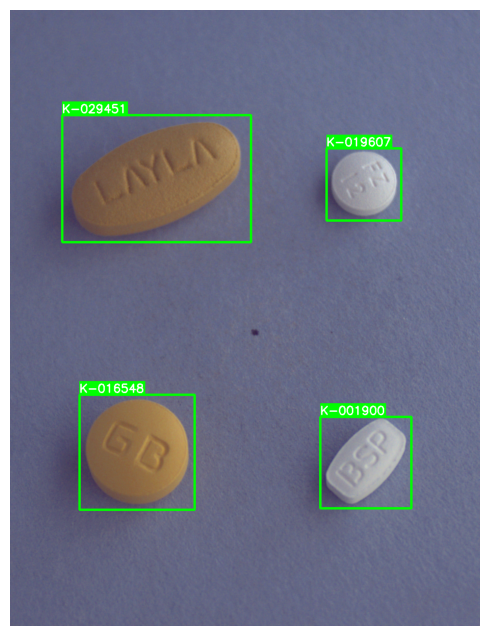

In [5]:
#@title 이미지 + Bounding Box 시각화

def draw_bbox_on_image(img_path, annotation_path):

    img_info = get_ann_for_image(img_path, annotation_path)
    
    if img_info is not None:
        # image
        img = cv2.imread(img_info['image'])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # bbox
        box_color = (0,255,0)
        text_color = (255,255,255)
        thickness = 3

        for bbox, label in zip(img_info['bboxes'], img_info['labels']):
            x, y, w, h = bbox

            x_max = int(x + w)
            y_max = int(y + h)
            x_min, y_min = int(x), int(y)

            # 사각형 그리기
            cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), box_color, thickness)
            # 텍스트
            text = str(label)
            # 텍스트 크기 측정
            (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)

            # 텍스트 가독성을 위한 배경 상자
            cv2.rectangle(img_rgb, (x_min, y_min - text_h - 10), (x_min + text_w, y_min), box_color, -1)
            cv2.putText(img_rgb, text, (x_min, y_min-5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, text_color, 2)

        plt.figure(figsize=(8,8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
    else:
        print('이미지, annotation정보 로드 실패')



# 샘플 출력
sample_img_path = os.path.join(train_img_path, train_imgs[0])
draw_bbox_on_image(sample_img_path, train_ann_path)


In [6]:
#@title 알약 종류 분포 및 불균형 분석

label_list = []

for image in train_imgs:
    image_path = os.path.join(train_img_path, image)
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    # 이미지 파일명에서 조합 ID 추출
    group_id = image_name.split('_')[0]
    dir_name = f'{group_id}_json'

    ann_path = os.path.join(train_ann_path, dir_name)
    # 알약 종류는 json파일에 접근할 필요 없이 폴더명으로 구할 수 있다. 
    for ann_dir in os.listdir(ann_path):
        label_list.append(ann_dir)

            

# 알약 종류 분포 및 불균형 분석
value_counts = dict(Counter(label_list))

print('[알약 종류 분포 및 불균형 분석]')
print(f'- 종류 및 count: {value_counts}')
print(f'- 알약 종류: {len(value_counts)}가지')
print(f'- 가장 많이 등장한 알약의 등장횟수: {max(value_counts.values())}')
print(f'- 가장 적게 등장한 알약의 등장횟수: {min(value_counts.values())}')


[알약 종류 분포 및 불균형 분석]
- 종류 및 count: {'K-001900': 15, 'K-016548': 18, 'K-019607': 6, 'K-029451': 3, 'K-033009': 3, 'K-021771': 3, 'K-027926': 3, 'K-024850': 3, 'K-029345': 6, 'K-016551': 3, 'K-033208': 3, 'K-002483': 9, 'K-003743': 3, 'K-012778': 6, 'K-013395': 3, 'K-012081': 3, 'K-025438': 6, 'K-019552': 3, 'K-022362': 3, 'K-003351': 157, 'K-003832': 20, 'K-016232': 21, 'K-016262': 23, 'K-016688': 8, 'K-020238': 20, 'K-021325': 22, 'K-022074': 16, 'K-029667': 18, 'K-035206': 37, 'K-036637': 19, 'K-038162': 18, 'K-013900': 15, 'K-018357': 13, 'K-019232': 17, 'K-020014': 17, 'K-031863': 12, 'K-032310': 15, 'K-033880': 17, 'K-041768': 16, 'K-018147': 15, 'K-003483': 45, 'K-020877': 12, 'K-030308': 9, 'K-034597': 3, 'K-022347': 9, 'K-025469': 12, 'K-019861': 6, 'K-028763': 9, 'K-027733': 12, 'K-025367': 12, 'K-031885': 3, 'K-027777': 3, 'K-003544': 6, 'K-004543': 6, 'K-012247': 3, 'K-027993': 3}
- 알약 종류: 56가지
- 가장 많이 등장한 알약의 등장횟수: 157
- 가장 적게 등장한 알약의 등장횟수: 3


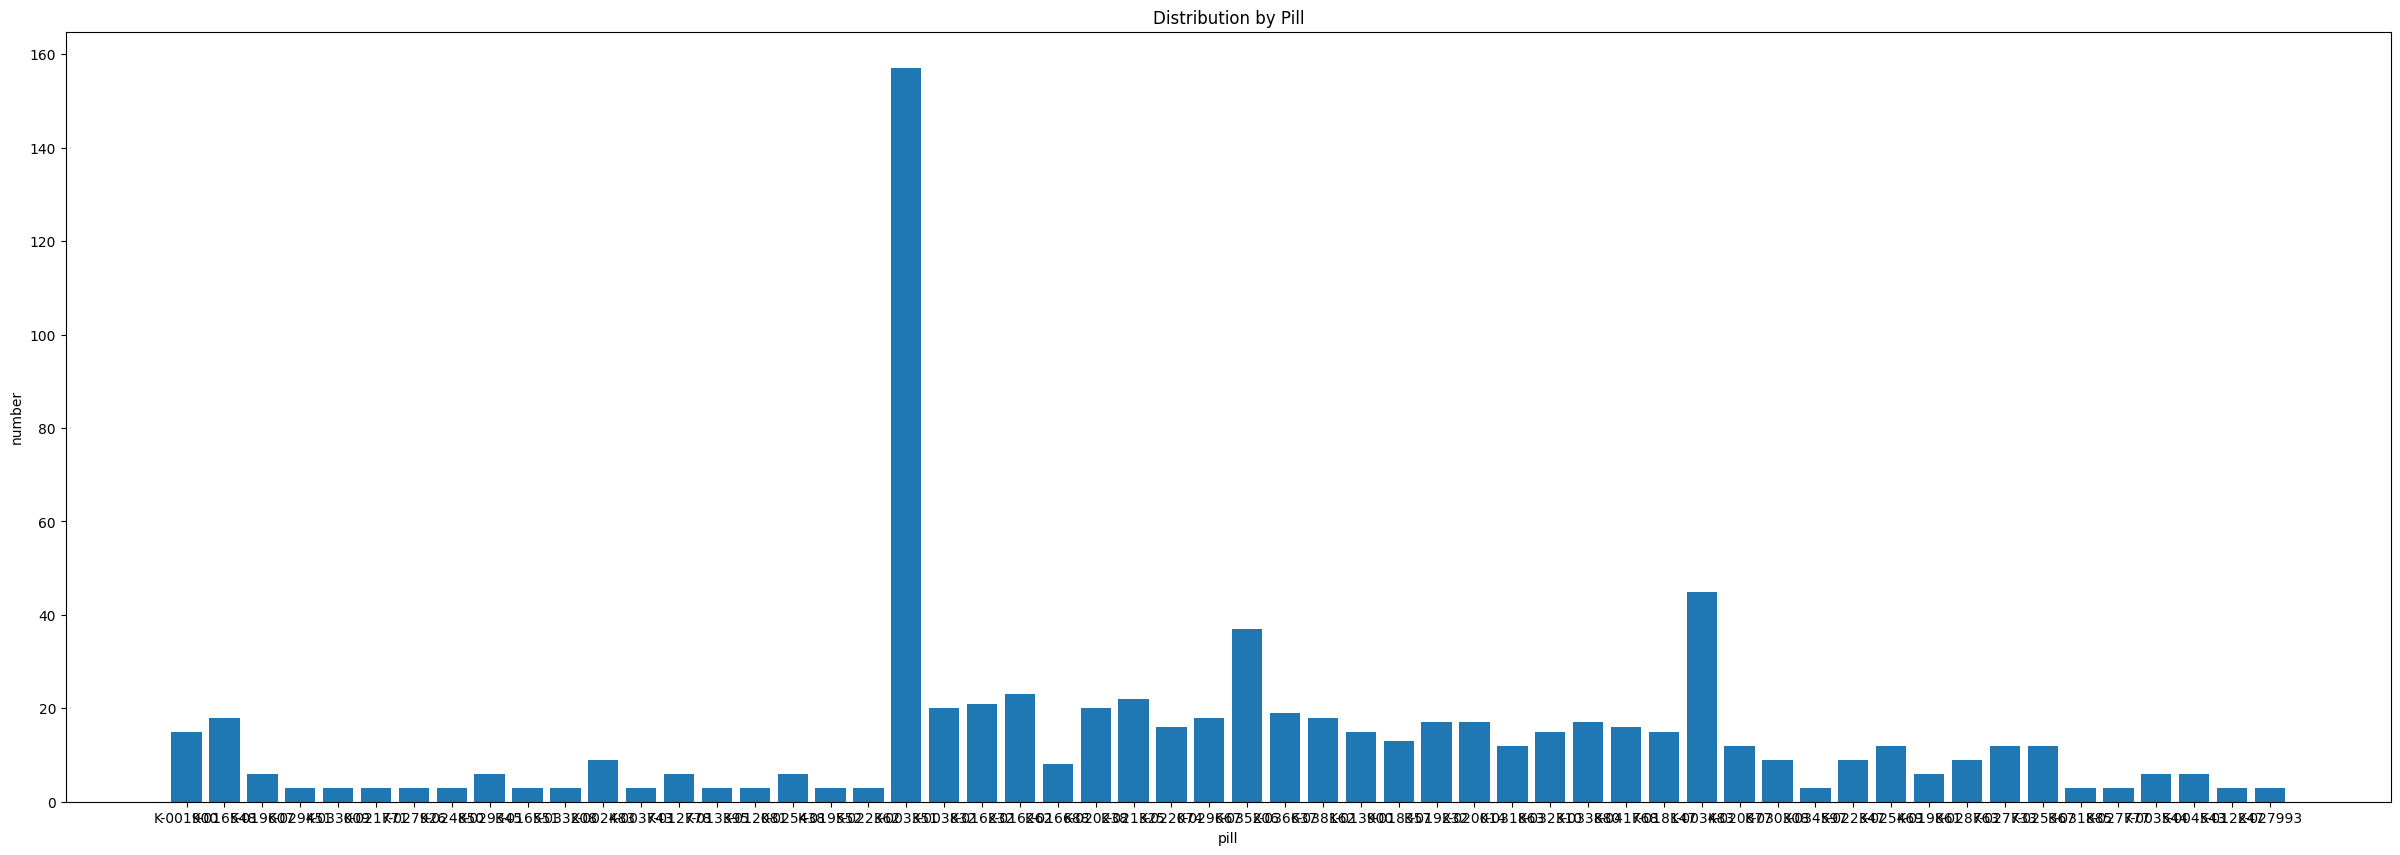

In [7]:
# 간략한 시각화
plt.figure(figsize=(30,10))

plt.bar(value_counts.keys(), value_counts.values())
plt.title('Distribution by Pill')
plt.xlabel('pill')
plt.ylabel('number')
plt.show()

알약 종류별 데이터의 개수가 불규칙하게 분포한다는 사실을 알 수 있음  
-> 필요에 따라 데이터 증강 고려

In [8]:
# Bounding Box 크기 및 가로세로 비율 분석

wh_list = []
for image in train_imgs:
    image_path = os.path.join(train_img_path, image)
    image_info = get_ann_for_image(image_path, train_ann_path)

    bboxes = image_info['bboxes']
    for bbox in bboxes:
        wh_list.append(bbox[2:]) # w,h만 추출

bbox_sizes = []
aspect_ratio = []   #가로세로 비율

for wh in wh_list:
    w, h = wh
    bbox_sizes.append(w*h)
    aspect_ratio.append(w/h)

bbox_sizes = sorted(bbox_sizes)
aspect_ratio = sorted(aspect_ratio)

size_value_counts = dict(Counter(bbox_sizes))
ratio_value_counts = dict(Counter(aspect_ratio))
print(f'- Bounding Box 면적(w*h): {size_value_counts}')
print(f'- Bounding Box 비율(w/h): {ratio_value_counts}')

- Bounding Box 면적(w*h): {23250: 1, 23550: 1, 24490: 1, 24645: 1, 25120: 1, 25125: 1, 25146: 1, 25326: 1, 25754: 1, 25929: 1, 26000: 2, 27324: 1, 27641: 1, 28968: 1, 29952: 1, 31243: 1, 32745: 1, 32760: 2, 32761: 1, 32942: 2, 33123: 2, 33124: 1, 33264: 1, 33294: 3, 33304: 4, 33306: 2, 33480: 1, 33485: 2, 33488: 5, 33489: 2, 33660: 1, 33666: 2, 33670: 5, 33672: 3, 33847: 1, 33852: 4, 33855: 6, 33856: 1, 34020: 1, 34034: 1, 34038: 2, 34040: 4, 34216: 2, 34221: 1, 34224: 4, 34354: 1, 34368: 1, 34390: 1, 34398: 1, 34404: 4, 34408: 3, 34410: 5, 34496: 1, 34571: 1, 34587: 3, 34592: 2, 34595: 4, 34596: 1, 34650: 1, 34736: 1, 34776: 1, 34780: 2, 34782: 1, 34960: 3, 34965: 6, 34969: 1, 35035: 1, 35150: 1, 35156: 2, 35335: 4, 35340: 1, 35343: 1, 35344: 1, 35520: 1, 35526: 2, 35530: 1, 35532: 4, 35696: 1, 35705: 1, 35712: 1, 35717: 3, 35720: 3, 35898: 1, 35904: 1, 35908: 2, 35910: 7, 36084: 2, 36091: 1, 36099: 3, 36150: 1, 36270: 1, 36278: 1, 36284: 1, 36288: 1, 36290: 4, 36480: 3, 36646: 1, 36660

Bounding Box 면적과 weight/height 비율 모두 특정한 규칙 없이 다양하게 분포

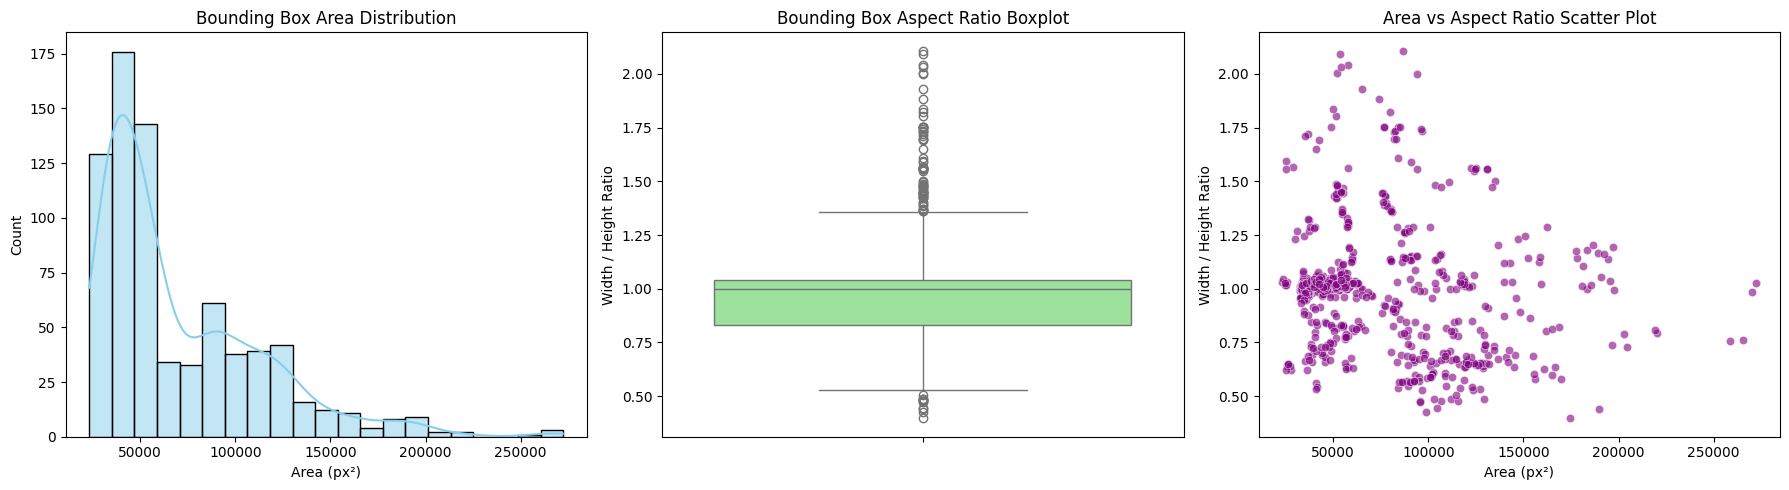

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 면적 히스토그램
sns.histplot(bbox_sizes, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Bounding Box Area Distribution')
axes[0].set_xlabel('Area (px²)')

# 2. 비율 박스플롯
sns.boxplot(y=aspect_ratio, ax=axes[1], color='lightgreen')
axes[1].set_title('Bounding Box Aspect Ratio Boxplot')
axes[1].set_ylabel('Width / Height Ratio')

# 3. 면적 vs 비율 산점도
sns.scatterplot(x=bbox_sizes, y=aspect_ratio, ax=axes[2], alpha=0.6, color='purple')
axes[2].set_title('Area vs Aspect Ratio Scatter Plot')
axes[2].set_xlabel('Area')
axes[2].set_ylabel('Width / Height Ratio')

plt.tight_layout()
plt.show()

In [10]:
#@title 이미지당 알약 개수 분포 파악
pills_per_image = []    # 이미지 당 알약 개수를 저장할 리스트
for image in train_imgs:
    image_path = os.path.join(train_img_path, image)
    image_name = image.split('.')[0]

    group_id = image_name.split('_')[0]
    folder_name = f'{group_id}_json'
    folder_path = os.path.join(train_ann_path, folder_name)
    pills_per_image.append(len(os.listdir(folder_path)))

value_counts = dict(Counter(pills_per_image))
print(f'이미지당 알약 개수 분포: {value_counts}')

이미지당 알약 개수 분포: {4: 75, 3: 157}
